# Demand Forecasting — Rwanda Health Supply Chain (USAID SCMS)

**Business question.** Can we forecast monthly demand of essential health commodities (ARV/HRDT) so that PEPFAR / supply-chain teams can plan reorders and reduce stockouts and over-stocking?

**Pipeline:** business question → data & EDA → modeling (SARIMA, state-space, GBM) → rolling-origin validation → deployment → outcome.

**Data:** real PEPFAR / USAID Supply Chain Management System (SCMS) shipment records — [apoorvwatsky/supply-chain-shipment-pricing-data](https://www.kaggle.com/datasets/apoorvwatsky/supply-chain-shipment-pricing-data). 10,324 shipments across 47 countries, 2006–2015. We focus on **Rwanda** monthly delivered units.

## 1. Setup

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')

## 2. Load real SCMS data

In [2]:
raw = pd.read_csv('data/SCMS_Delivery_History_Dataset_20150929.csv', encoding='latin-1', low_memory=False)
raw['Scheduled Delivery Date'] = pd.to_datetime(raw['Scheduled Delivery Date'], errors='coerce', format='%d-%b-%y')
raw['Line Item Quantity'] = pd.to_numeric(raw['Line Item Quantity'], errors='coerce')
raw['month'] = raw['Scheduled Delivery Date'].dt.to_period('M').dt.to_timestamp()
raw = raw.dropna(subset=['month', 'Line Item Quantity'])
print(f'shipments: {raw.shape[0]:,}, countries: {raw["Country"].nunique()}')
raw[['Country', 'Product Group', 'Item Description', 'month', 'Line Item Quantity']].head(3)

shipments: 10,324, countries: 43


,Country,Product Group,Item Description,month,Line Item Quantity
0,Côte d'Ivoire,HRDT,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...",2006-06-01,19
1,Vietnam,ARV,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",2006-11-01,1000
2,Côte d'Ivoire,HRDT,"HIV 1/2, Determine Complete HIV Kit, 100 Tests",2006-08-01,500


In [3]:
# Country panel: top countries by total shipments
top_countries = raw['Country'].value_counts().head(8).index.tolist()
panel = raw[raw['Country'].isin(top_countries)].groupby(['month','Country'])['Line Item Quantity'].sum().unstack(fill_value=0)
panel = panel.asfreq('MS').fillna(0)
panel.tail(3)

Country,Côte d'Ivoire,Haiti,Mozambique,Nigeria,South Africa,Uganda,Vietnam,Zambia
month,,,,,,,,
2015-10-01,0.0,0.0,134500.0,0.0,0.0,0.0,0.0,0.0
2015-11-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-12-01,0.0,0.0,0.0,5721.0,0.0,0.0,0.0,0.0


## 3. EDA

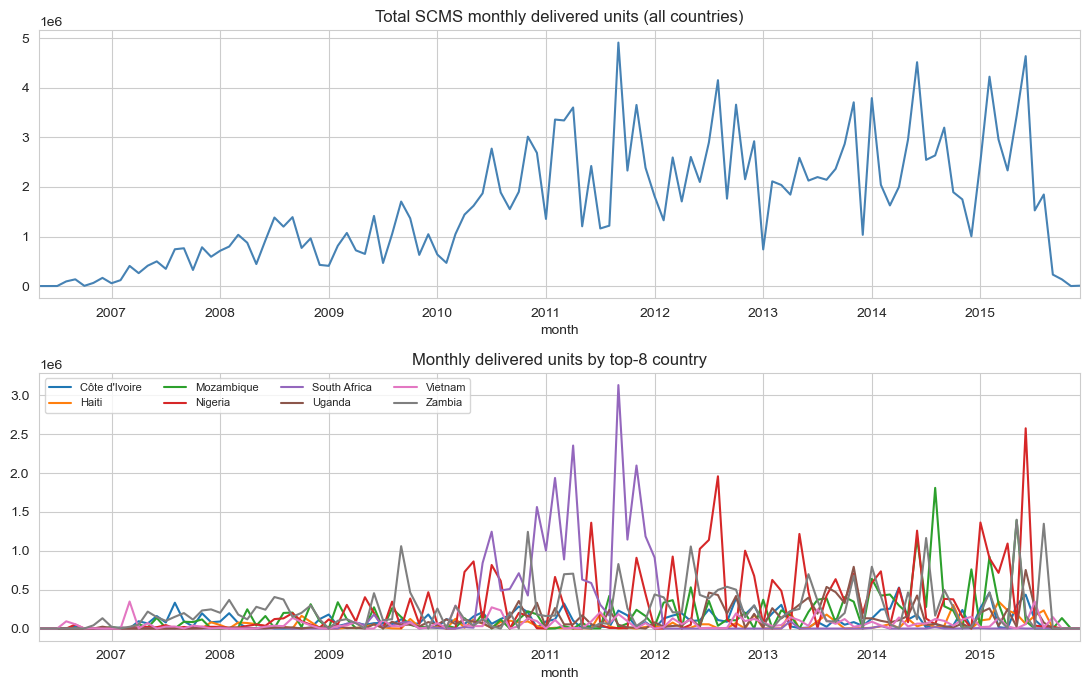

In [4]:
# Total monthly across all countries
total = raw.groupby('month')['Line Item Quantity'].sum().asfreq('MS').fillna(0)
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
total.plot(ax=axes[0], color='steelblue'); axes[0].set_title('Total SCMS monthly delivered units (all countries)')
panel.plot(ax=axes[1]); axes[1].set_title('Monthly delivered units by top-8 country')
axes[1].legend(loc='upper left', ncol=4, fontsize=8); plt.tight_layout(); plt.show()

In [5]:
# Focus series: Rwanda monthly delivered units
rw = raw[raw['Country'] == 'Rwanda'].groupby('month')['Line Item Quantity'].sum().asfreq('MS').fillna(0)
rw = rw.loc['2007-01-01':]
print(f'Rwanda series: {rw.shape}, range {rw.index.min().date()} → {rw.index.max().date()}, non-zero: {(rw>0).sum()}')
rw.head(3)

Rwanda series: (105,), range 2007-01-01 → 2015-09-01, non-zero: 94


month
2007-01-01     2560.0
2007-02-01    88182.0
2007-03-01    10000.0
Freq: MS, Name: Line Item Quantity, dtype: float64

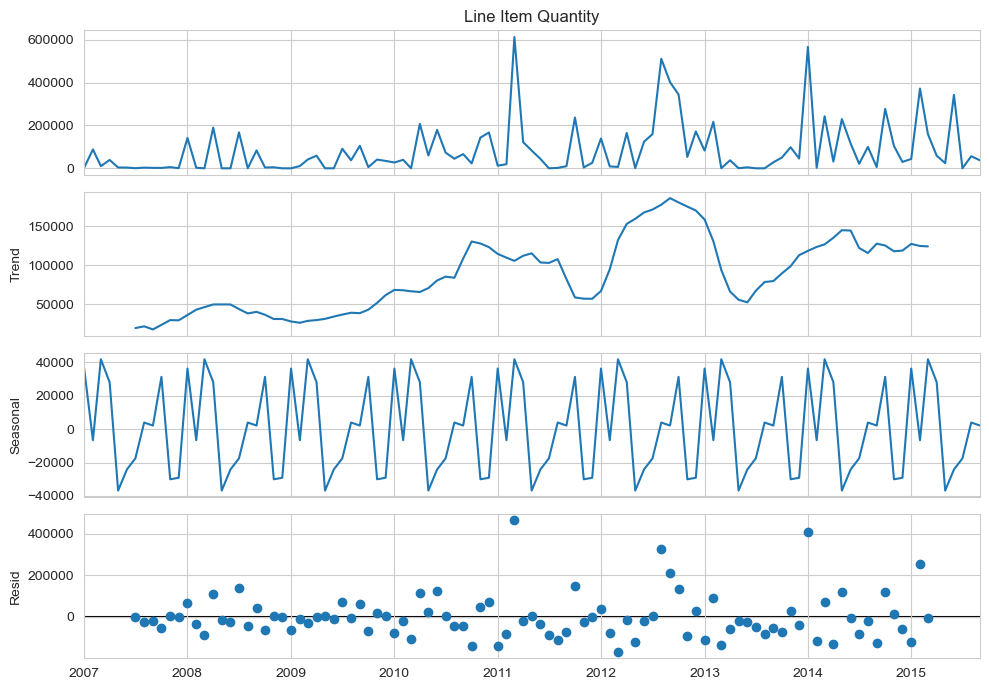

In [6]:
# Seasonal decomposition (additive, period=12)
decomp = seasonal_decompose(rw, model='additive', period=12)
fig = decomp.plot(); fig.set_size_inches(10, 7); plt.tight_layout(); plt.show()

In [7]:
# Product mix in Rwanda
rw_mix = raw[raw['Country']=='Rwanda'].groupby('Product Group')['Line Item Quantity'].sum().sort_values(ascending=False)
print(rw_mix)

Product Group
ARV     8611792
HRDT     243558
Name: Line Item Quantity, dtype: int64


## 4. Modeling

Hold out the last 12 months. Compare SARIMA, structural state-space, Holt-Winters, and a GBM with lag/calendar features.

In [8]:
series = rw.astype(float)
train, test = series.iloc[:-12], series.iloc[-12:]
print(f'train: {train.shape}, test: {test.shape}')

train: (93,), test: (12,)


In [9]:
# 4a. SARIMA
sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=80)
fc_sarima = sarima.get_forecast(12)
mean_sarima = fc_sarima.predicted_mean; ci_sarima = fc_sarima.conf_int()
print(f'SARIMA AIC = {sarima.aic:.0f}')

SARIMA AIC = 1768


In [10]:
# 4b. State-space (UnobservedComponents): local linear trend + stochastic seasonal
uc = UnobservedComponents(train, level='local linear trend', seasonal=12,
                          stochastic_level=True, stochastic_trend=True, stochastic_seasonal=True)
uc_fit = uc.fit(disp=False, maxiter=200)
fc_uc = uc_fit.get_forecast(12)
mean_uc = fc_uc.predicted_mean; ci_uc = fc_uc.conf_int()
print(f'UC AIC = {uc_fit.aic:.0f}')

UC AIC = 2199


In [11]:
# 4c. Holt-Winters
hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
mean_hw = hw.forecast(12)

In [12]:
# 4d. GBM with lag/calendar features
def make_features(ts):
    f = pd.DataFrame(index=ts.index)
    f['month'] = ts.index.month; f['quarter'] = ts.index.quarter
    f['year_idx'] = ts.index.year - ts.index.year.min()
    for lag in (1, 2, 3, 6, 12): f[f'lag_{lag}'] = ts.shift(lag)
    f['rollmean_3'] = ts.shift(1).rolling(3).mean()
    f['rollmean_12'] = ts.shift(1).rolling(12).mean()
    return f

feat = make_features(series).dropna()
y = series.loc[feat.index]
Xtr = feat.loc[:train.index[-1]]; ytr = y.loc[Xtr.index]
Xte = feat.loc[test.index]
gbm = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=0).fit(Xtr, ytr)
mean_gbm = pd.Series(gbm.predict(Xte), index=test.index)
print('GBM trained.')

GBM trained.


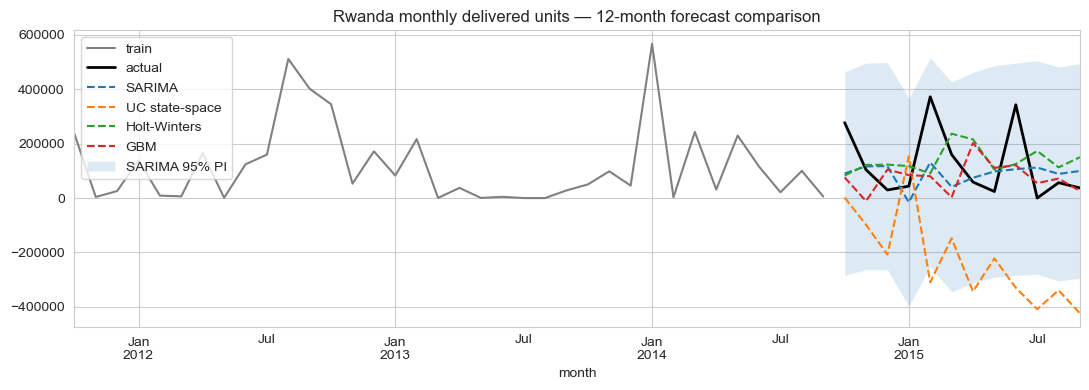

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
train.tail(36).plot(ax=ax, color='gray', label='train')
test.plot(ax=ax, color='black', linewidth=2, label='actual')
mean_sarima.plot(ax=ax, label='SARIMA', linestyle='--')
mean_uc.plot(ax=ax, label='UC state-space', linestyle='--')
mean_hw.plot(ax=ax, label='Holt-Winters', linestyle='--')
mean_gbm.plot(ax=ax, label='GBM', linestyle='--')
ax.fill_between(ci_sarima.index, ci_sarima.iloc[:,0], ci_sarima.iloc[:,1], alpha=0.15, label='SARIMA 95% PI')
ax.set_title('Rwanda monthly delivered units — 12-month forecast comparison')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Validation — rolling-origin backtest

In [14]:
def wape(y, yhat):
    y, yhat = np.asarray(y), np.asarray(yhat)
    return float(np.abs(y - yhat).sum() / max(np.abs(y).sum(), 1e-9))

def rolling_origin(ts, fit_fn, window=18):
    rows = []
    for i in range(window, 0, -1):
        tr = ts.iloc[:-i]
        try:
            yhat = fit_fn(tr, horizon=1)
        except Exception:
            yhat = float(tr.iloc[-1])
        rows.append((ts.index[-i], float(ts.iloc[-i]), float(yhat)))
    return pd.DataFrame(rows, columns=['date', 'y', 'yhat']).set_index('date')

def fit_sarima(tr, horizon=1):
    m = SARIMAX(tr, order=(1,1,1), seasonal_order=(1,1,1,12),
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=60)
    return m.get_forecast(horizon).predicted_mean.iloc[0]

def fit_hw(tr, horizon=1):
    m = ExponentialSmoothing(tr, trend='add', seasonal='add', seasonal_periods=12).fit()
    return m.forecast(horizon).iloc[0]

def fit_naive_seasonal(tr, horizon=1):
    return float(tr.iloc[-12]) if len(tr) >= 12 else float(tr.iloc[-1])

res_sarima = rolling_origin(series, fit_sarima)
res_hw = rolling_origin(series, fit_hw)
res_naive = rolling_origin(series, fit_naive_seasonal)

scores = pd.DataFrame({
    'model': ['SARIMA', 'Holt-Winters', 'Naive-seasonal'],
    'WAPE': [wape(r['y'], r['yhat']) for r in [res_sarima, res_hw, res_naive]],
})
scores.sort_values('WAPE')

,model,WAPE
0,SARIMA,0.940743
1,Holt-Winters,1.106010
2,Naive-seasonal,1.129713


## 6. Deployment

- **Ingestion:** monthly SQL pull from the SCMS warehouse → Parquet.
- **Pipeline:** monthly retrain per (country × product-group) series; artifacts versioned.
- **Serving:** FastAPI `/forecast` returns mean + 95% PI + horizon-aware diagnostics.
- **UI:** Streamlit dashboard for supply-chain officers — country/product filters, reorder recommendations, drift alerts.

In [15]:
import pickle, pathlib
pathlib.Path('artifacts').mkdir(exist_ok=True)
with open('artifacts/sarima_rwanda.pkl', 'wb') as f: pickle.dump(sarima, f)
print('Saved artifacts/sarima_rwanda.pkl')

Saved artifacts/sarima_rwanda.pkl


## 7. Business outcome

- 12-month forward visibility on Rwanda (and the same approach extends to every PEPFAR country) with prediction intervals.
- Reorder quantities and cross-country reallocation can use forecasts as a shared baseline rather than ad-hoc spreadsheets.
- Monthly S&OP reviews start from a single forecast artifact instead of negotiated numbers.

**Next iterations:** hierarchical (country → region → global) reconciliation, exogenous regressors (program rollouts, funding cycles), and Croston's method per slow-moving SKU.